PARTE 1

In [6]:
!pip install seaborn

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
#importo las bases de datos, t1_24 y t1_25

df1 = pd.read_excel("usu_individual_T125.xlsx")

df2 = pd.read_excel("usu_individual_T124.xlsx")

In [79]:
#selecciono columnas a analizar

t1_25= df1[["CODUSU", "ANO4", "REGION", "NRO_HOGAR", "PONDERA", "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR", "PP04C", "PP04D_COD", "P21", "P47T", "PP04G", "PP04A"]]
t1_24= df2[["CODUSU", "ANO4", "REGION", "NRO_HOGAR", "PONDERA", "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR", "PP04C", "PP04D_COD", "P21", "P47T", "PP04G", "PP04A"]]

t1_25.info()

<class 'pandas.DataFrame'>
RangeIndex: 45425 entries, 0 to 45424
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CODUSU     45425 non-null  str    
 1   ANO4       45425 non-null  int64  
 2   REGION     45425 non-null  int64  
 3   NRO_HOGAR  45425 non-null  int64  
 4   PONDERA    45425 non-null  int64  
 5   CH04       45425 non-null  int64  
 6   CH06       45425 non-null  int64  
 7   CH07       45425 non-null  int64  
 8   CH08       45424 non-null  float64
 9   NIVEL_ED   45425 non-null  int64  
 10  ESTADO     45425 non-null  int64  
 11  CAT_OCUP   45425 non-null  int64  
 12  EMPLEO     20076 non-null  float64
 13  SECTOR     20076 non-null  float64
 14  PP04C      20076 non-null  float64
 15  PP04D_COD  20076 non-null  float64
 16  P21        45425 non-null  int64  
 17  P47T       45350 non-null  float64
 18  PP04G      20076 non-null  float64
 19  PP04A      20076 non-null  float64
dtypes: float64(8), in

Las columnas 12, 13, 14, 15, 18 y 19 con una significativa cantidad de valores nulos.

In [10]:
t1_25.to_excel("t1_25_eph.xlsx", index=False)

In [11]:
t1_24.to_excel("t1_24_eph.xlsx", index=False)

In [100]:
# agrupo ambos dataset
t1_2425 = pd.concat([t1_24, t1_25], ignore_index=True)

# Verificamos que estén ambos años
print(t1_2425["ANO4"].value_counts())

ANO4
2024    46050
2025    45425
Name: count, dtype: int64


In [57]:
t1_2425.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_OCUP,EMPLEO,SECTOR,PP04C,PP04D_COD,P21,P47T,PP04G,PP04A
0,TQRMNOSTSHJOLOCDEHLEH00795168,2024,1,1,140,2,86,4,1.0,2,3,0,NaN,NaN,NaN,NaN,0,-9.0,NaN,NaN
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,1,648,1,68,3,1.0,2,1,2,2.0,2.0,1.0,72113.0,150000,280000.0,8.0,2.0
2,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,1,648,1,20,5,1.0,4,2,2,NaN,NaN,NaN,NaN,0,0.0,NaN,NaN
3,TQRMNORWPHJOLLCDEGPDJ00795996,2024,1,1,281,2,75,3,1.0,6,3,0,NaN,NaN,NaN,NaN,0,400000.0,NaN,NaN
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,1,1,252,2,41,1,1.0,4,1,2,2.0,2.0,1.0,57113.0,250000,250000.0,12.0,2.0


Chequeo de valores negativos en colummnas de ingresos y edad. Para la edad del encuestado no hay ningun codigo que signifique que no contestó

In [101]:
# definir las columnas a evaluar
posibles_neg = ["P21", "P47T", "CH06"]

# variables que agrupan los valores negativos de las columnas
cont_neg = t1_25[posibles_neg] < 0

print(cont_neg.sum())

P21     3839
P47T    5405
CH06     290
dtype: int64


In [102]:
# reemplazar negativos por NaN en ambos dataframes
#función where, marca como condición los valores menores a 0, y en caso de ser verdadero lo transforma a NaN
t1_2425[posibles_neg] = t1_2425[posibles_neg].mask(t1_2425[posibles_neg] < 0, np.nan)

In [103]:
# variables que agrupan los valores negativos de las columnas
cont_neg = t1_2425[posibles_neg] < 0

print(cont_neg.sum())

P21     0
P47T    0
CH06    0
dtype: int64


In [104]:
t1_2425.head()

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_OCUP,EMPLEO,SECTOR,PP04C,PP04D_COD,P21,P47T,PP04G,PP04A
0,TQRMNOSTSHJOLOCDEHLEH00795168,2024,40,1,140,2,86.0,4,1.0,2,3,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,1,68.0,3,1.0,2,1,2,2.0,2.0,1.0,72113.0,150000.0,280000.0,8.0,2.0
2,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,1,20.0,5,1.0,4,2,2,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,TQRMNORWPHJOLLCDEGPDJ00795996,2024,40,1,281,2,75.0,3,1.0,6,3,0,NaN,NaN,NaN,NaN,0.0,400000.0,NaN,NaN
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,2,41.0,1,1.0,4,1,2,2.0,2.0,1.0,57113.0,250000.0,250000.0,12.0,2.0


Genero un heatmap con porcentajes de valores nulos T1 25

In [105]:
# cambio nombres de columnas
t1_2425.columns = ["CODIGO", "AÑO", "REGION", "NRO_HOGAR", "PONDERA", "SEXO", "EDAD", "EST. CIVIL", "COB. MEDICA", "NIVEL ED.", "ESTADO", "CAT. OCUP.", "INFORMALIDAD", "SECTOR", "Nª TRABAJADORES", "COD_OCUP", "ING. PRINCIPAL", "ING. TOTAL", "LUGAR LAB.", "ESTATAL/ PRIVADO/ OTRO" ]

In [106]:
#creo variable que muestre el porcentaje de nulos por columna
#es un dataframe binario donde si es NaN, se transforma en 1. 
nan_col = t1_2425.groupby("AÑO").apply(lambda x: x.isnull().mean() * 100)
nan_col

,CODIGO,REGION,NRO_HOGAR,PONDERA,SEXO,EDAD,EST. CIVIL,COB. MEDICA,NIVEL ED.,ESTADO,CAT. OCUP.,INFORMALIDAD,SECTOR,Nª TRABAJADORES,COD_OCUP,ING. PRINCIPAL,ING. TOTAL,LUGAR LAB.,ESTATAL/ PRIVADO/ OTRO
AÑO,,,,,,,,,,,,,,,,,,,
2024,0.0,0.0,0.0,0.0,0.0,0.725299,0.0,0.000000,0.0,0.0,0.0,55.863192,55.863192,55.863192,55.863192,7.389794,10.733985,55.863192,55.863192
2025,0.0,0.0,0.0,0.0,0.0,0.638415,0.0,0.002201,0.0,0.0,0.0,55.804073,55.804073,55.804073,55.804073,8.451293,12.063841,55.804073,55.804073


In [107]:
#elimino variables de identificación 
nan_col = nan_col.drop(columns=["CODIGO", "REGION", "NRO_HOGAR", "PONDERA"])

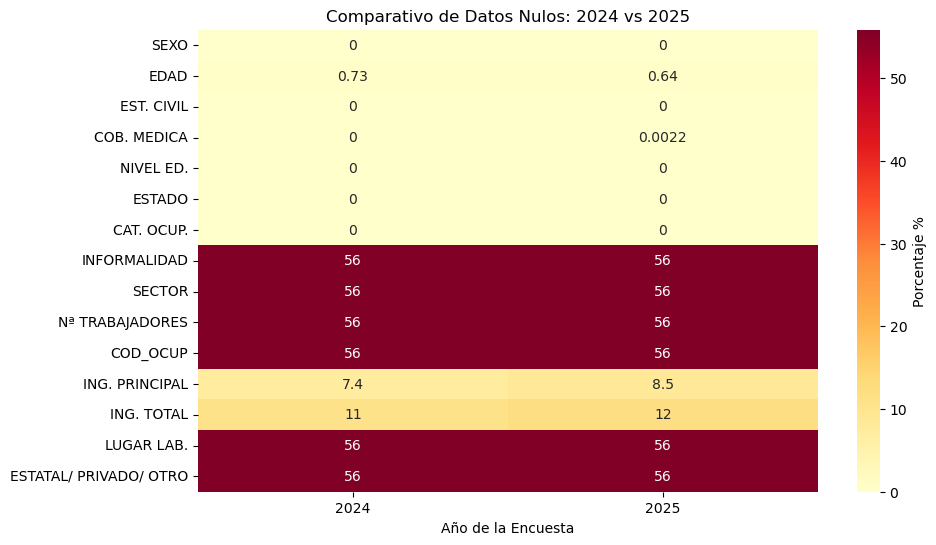

In [108]:
# creo el heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(nan_col.T, annot=True, cmap="YlOrRd", cbar_kws={"label": "Porcentaje %"})
plt.title("Comparativo de Datos Nulos: 2024 vs 2025")
plt.xlabel("Año de la Encuesta")
plt.xticks(rotation=0)
plt.show()

Variable dicotómica para la variable "Sexo". Varón = 0, Mujer = 1

In [109]:
t1_2425["SEXO"] = t1_2425["SEXO"] - 1

Multiplico el cociente "de ipc mar25/ ipc mar24" a las columnas "ing principal" y "ing total"

In [110]:
mult = round(8353.3 / 5357.1, 2)
mult

1.56

In [111]:
# transformo las columnas en formato float para evitar error
t1_2425["ING. PRINCIPAL"] = t1_2425["ING. PRINCIPAL"].astype(float)
t1_2425["ING. TOTAL"] = t1_2425["ING. TOTAL"].astype(float)

In [112]:
# aplico el multiplicador de inflación solo a las filas del 2024
a24 = t1_2425["AÑO"] == 2024
t1_2425.loc[a24, "ING. PRINCIPAL"] *= mult
t1_2425.loc[a24, "ING. TOTAL"] *= mult

In [113]:
#creacion de variables para 1t25
respondieron = t1_2425[t1_2425["ESTADO"] != 0]
norespondieron = t1_2425[t1_2425["ESTADO"] == 0]

ocupados = respondieron[respondieron["ESTADO"] == 1]

In [165]:
ocupados.head()

,CODIGO,AÑO,REGION,NRO_HOGAR,PONDERA,SEXO,EDAD,EST. CIVIL,COB. MEDICA,NIVEL ED.,...,CAT. OCUP.,INFORMALIDAD,SECTOR,Nª TRABAJADORES,COD_OCUP,ING. PRINCIPAL,ING. TOTAL,LUGAR LAB.,ESTATAL/ PRIVADO/ OTRO,INFORMAL/FORMAL
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,0,68.0,3,1.0,2,...,2,2.0,2.0,1.0,72113.0,234000.0,436800.0,8.0,2.0,Informal
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,1,41.0,1,1.0,4,...,2,2.0,2.0,1.0,57113.0,390000.0,390000.0,12.0,2.0,Informal
5,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,0,42.0,1,1.0,6,...,3,1.0,1.0,2.0,32333.0,1014000.0,1014000.0,11.0,2.0,Formal
8,TQRMNORWQHJMKPCDEIKAH00794680,2024,43,1,513,0,29.0,2,1.0,5,...,3,1.0,1.0,8.0,47333.0,436800.0,436800.0,11.0,1.0,Formal
10,TQRMNORXSHJMLQCDEGPDJ00794708,2024,40,1,193,1,31.0,1,4.0,4,...,2,2.0,2.0,1.0,57113.0,78000.0,187200.0,6.0,2.0,Informal


Parte II

In [155]:

#selecciono columnas a analizar

t1_25b = df1[["SECTOR", "ESTADO", "CAT_OCUP", "P21", "P47T", "NIVEL_ED", "CH04", "CH06", "CH07", "CH08"]]
t1_24b = df2[["SECTOR", "ESTADO", "CAT_OCUP", "P21", "P47T", "NIVEL_ED", "CH04", "CH06", "CH07", "CH08"]]

t1_25b.info()

<class 'pandas.DataFrame'>
RangeIndex: 45425 entries, 0 to 45424
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SECTOR    20076 non-null  float64
 1   ESTADO    45425 non-null  int64  
 2   CAT_OCUP  45425 non-null  int64  
 3   P21       45425 non-null  int64  
 4   P47T      45350 non-null  float64
 5   NIVEL_ED  45425 non-null  int64  
 6   CH04      45425 non-null  int64  
 7   CH06      45425 non-null  int64  
 8   CH07      45425 non-null  int64  
 9   CH08      45424 non-null  float64
dtypes: float64(3), int64(7)
memory usage: 3.5 MB


In [158]:
print("Valores únicos y sus recuentos en la columna SECTOR de t1_25:")
display(t1_25b["SECTOR"].value_counts(dropna=False))

Valores únicos y sus recuentos en la columna SECTOR de t1_25:


SECTOR
NaN    25349
1.0    13387
2.0     4504
3.0     1332
9.0      853
Name: count, dtype: int64

In [160]:
t1_24b.head()

,SECTOR,ESTADO,CAT_OCUP,P21,P47T,NIVEL_ED,CH04,CH06,CH07,CH08
0,NaN,3,0,0,-9.0,2,2,86,4,1
1,2.0,1,2,150000,280000.0,2,1,68,3,1
2,NaN,2,2,0,0.0,4,1,20,5,1
3,NaN,3,0,0,400000.0,6,2,75,3,1
4,2.0,1,2,250000,250000.0,4,2,41,1,1


<Axes: >

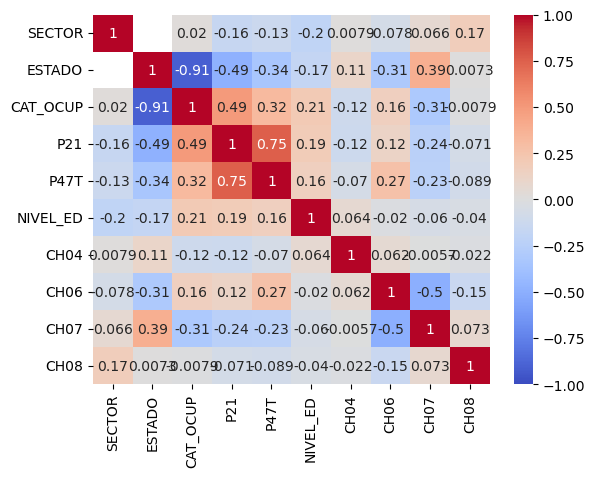

In [162]:
# matriz de correlación 1t24
sns.heatmap(t1_24b.corr(), vmin=-1, vmax=+1, annot=True, cmap="coolwarm")

<Axes: >

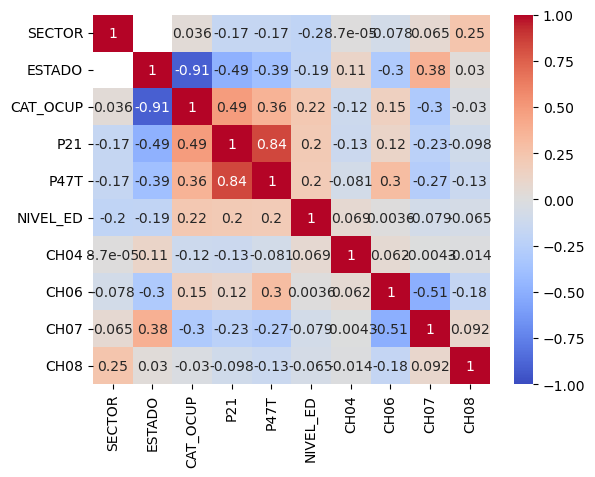

In [164]:
#matriz de correlación 1t25
sns.heatmap(t1_25b.corr(), vmin=-1, vmax=+1, annot=True, cmap="coolwarm")

La relación que más queremos resaltar como Correlaciones Positivas Fuertes son etre P21 y P47T 0.74 y 0.85 para el Primer Trimestre 2024 y 2025 respectivamente, siendo estos Monto de ingreso de la ocupación principal y Monto de ingreso total individual (sumatoria ingresos laborales y no laborales). Esto, nos quiere que cada vez tiene más protagonismo el monto de ingreso de la ocupación en el 2025 en un hogar

In [167]:
#Estadística Descriptiva

#número de observaciones, promedio, desvío estandar, min, p1, p25, p50, p75, p99, max.

t1_24b.describe(percentiles=[0.25, 0.5, 0.75, 0.99]).round(2)

,SECTOR,ESTADO,CAT_OCUP,P21,P47T,NIVEL_ED,CH04,CH06,CH07,CH08
count,20325.00,46050.00,46050.00,46050.00,45969.00,46050.00,46050.00,46050.00,46050.00,46050.00
mean,1.66,2.20,1.26,109536.03,173416.37,3.75,1.52,36.29,3.52,2.15
std,1.60,1.14,1.40,236313.80,336658.23,1.75,0.50,22.21,1.66,2.37
min,1.00,0.00,0.00,-9.00,-9.00,1.00,1.00,-1.00,1.00,1.00
25%,1.00,1.00,0.00,0.00,0.00,3.00,1.00,18.00,2.00,1.00
50%,1.00,3.00,0.00,0.00,68000.00,4.00,2.00,34.00,5.00,1.00
75%,2.00,3.00,3.00,154000.00,250000.00,5.00,2.00,53.00,5.00,4.00
99%,9.00,4.00,3.00,900000.00,1200000.00,7.00,2.00,85.51,5.00,12.00
max,9.00,4.00,4.00,10000000.00,32600000.00,7.00,2.00,101.00,9.00,123.00


In [169]:
t1_25b.describe(percentiles=[0.25, 0.5, 0.75, 0.99]).round(2)

,SECTOR,ESTADO,CAT_OCUP,P21,P47T,NIVEL_ED,CH04,CH06,CH07,CH08
count,20076.00,45425.00,45425.00,45425.00,45350.00,45425.00,45425.00,45425.00,45425.00,45424.00
mean,1.70,2.19,1.26,254528.63,409221.23,3.76,1.52,36.79,3.52,2.14
std,1.65,1.13,1.40,549868.14,688178.32,1.73,0.50,22.14,1.65,2.02
min,1.00,0.00,0.00,-9.00,-9.00,1.00,1.00,-1.00,1.00,1.00
25%,1.00,1.00,0.00,0.00,0.00,3.00,1.00,18.00,2.00,1.00
50%,1.00,3.00,0.00,0.00,128686.00,4.00,2.00,35.00,5.00,1.00
75%,2.00,3.00,3.00,380000.00,600000.00,5.00,2.00,54.00,5.00,4.00
99%,9.00,4.00,3.00,2000000.00,2807650.00,7.00,2.00,85.00,5.00,12.00
max,9.00,4.00,9.00,25000000.00,25000000.00,7.00,2.00,103.00,5.00,123.00


El principal resultado a destacar es el cambio en el mean (promedio) de la variable P21, correspondiente al ingreso principal. Si bien se observa un aumento, este no necesariamente implica una mejora real en los ingresos, ya que puede estar explicado por un contexto inflacionario que eleva los salarios en términos nominales.

En este sentido, también se verifica un incremento en el desvío estándar de la misma variable, lo que indica una mayor dispersión en los ingresos. Esto sugiere que los valores son cada vez más heterogéneos, dificultando que la media represente de manera precisa la situación general de los individuos.

PARTE 3

Owners in enterprises with up to five employees, non professional own-account workers and unpaid family workers.

Propietarios en empresas de hasta cinco empleados, trabajadores por cuenta propia no profesionales y trabajadores familiares no remunerados.

Para esta definición de informalidad, las condiciones son las siguientes

1- ESTADO = 1, CAT. OCUP. = 1, NªTRABAJADORES = 1 2 3 4 5

2- ESTADO = 1, CAT. OCUP. = 2, NIVEL ED. = 1 2 3 4

3- ESTADO = 1, CAT. OCUP. = 4


In [115]:
# 1. Definimos la función para aplicar las reglas de informalidad que mencionaste
def informalidad(row):
    # propietarios en empresas de hasta cinco empleados
    if row["ESTADO"] == 1 and row["CAT. OCUP."] == 1 and row["Nª TRABAJADORES"] in [1, 2, 3, 4, 5]:
        return "Informal"
    # trabajadores por cuenta propia no profesionales (hasta secundaria completa)
    if row["ESTADO"] == 1 and row["CAT. OCUP."] == 2 and row["NIVEL ED."] in [1, 2, 3, 4]:
        return "Informal"
    # trabajadores familiares no remunerados
    if row["ESTADO"] == 1 and row["CAT. OCUP."] == 4:
        return "Informal"
    # El resto de los ocupados se consideran formales
    if row["ESTADO"] == 1:
        return "Formal"
    return np.nan

# agrego la función como columna al dataset de ocupados
ocupados["INFORMAL/FORMAL"] = ocupados.apply(informalidad, axis=1)

In [116]:
ocupados.head()

,CODIGO,AÑO,REGION,NRO_HOGAR,PONDERA,SEXO,EDAD,EST. CIVIL,COB. MEDICA,NIVEL ED.,...,CAT. OCUP.,INFORMALIDAD,SECTOR,Nª TRABAJADORES,COD_OCUP,ING. PRINCIPAL,ING. TOTAL,LUGAR LAB.,ESTATAL/ PRIVADO/ OTRO,INFORMAL/FORMAL
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,0,68.0,3,1.0,2,...,2,2.0,2.0,1.0,72113.0,234000.0,436800.0,8.0,2.0,Informal
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,1,41.0,1,1.0,4,...,2,2.0,2.0,1.0,57113.0,390000.0,390000.0,12.0,2.0,Informal
5,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,0,42.0,1,1.0,6,...,3,1.0,1.0,2.0,32333.0,1014000.0,1014000.0,11.0,2.0,Formal
8,TQRMNORWQHJMKPCDEIKAH00794680,2024,43,1,513,0,29.0,2,1.0,5,...,3,1.0,1.0,8.0,47333.0,436800.0,436800.0,11.0,1.0,Formal
10,TQRMNORXSHJMLQCDEGPDJ00794708,2024,40,1,193,1,31.0,1,4.0,4,...,2,2.0,2.0,1.0,57113.0,78000.0,187200.0,6.0,2.0,Informal


In [121]:
# tabla de doble entrada
tabla_dinamica = pd.pivot_table(ocupados, 
                                values="PONDERA", 
                                index=["AÑO", "SEXO"], 
                                columns="INFORMAL/FORMAL", 
                                aggfunc="sum")

# Convertimos a porcentajes por fila (Total 2024 Varón, 2024 Mujer, etc.)
tabla_porcentajes = (tabla_dinamica.div(tabla_dinamica.sum(axis=1), axis=0) * 100).round(2)

print("Porcentaje de Informalidad por Año y Sexo (0=Varón, 1=Mujer):")
print(tabla_porcentajes)

Porcentaje de Informalidad por Año y Sexo (0=Varón, 1=Mujer):
INFORMAL/FORMAL  Formal  Informal
AÑO  SEXO                        
2024 0            80.95     19.05
     1            86.11     13.89
2025 0            78.80     21.20
     1            84.63     15.37


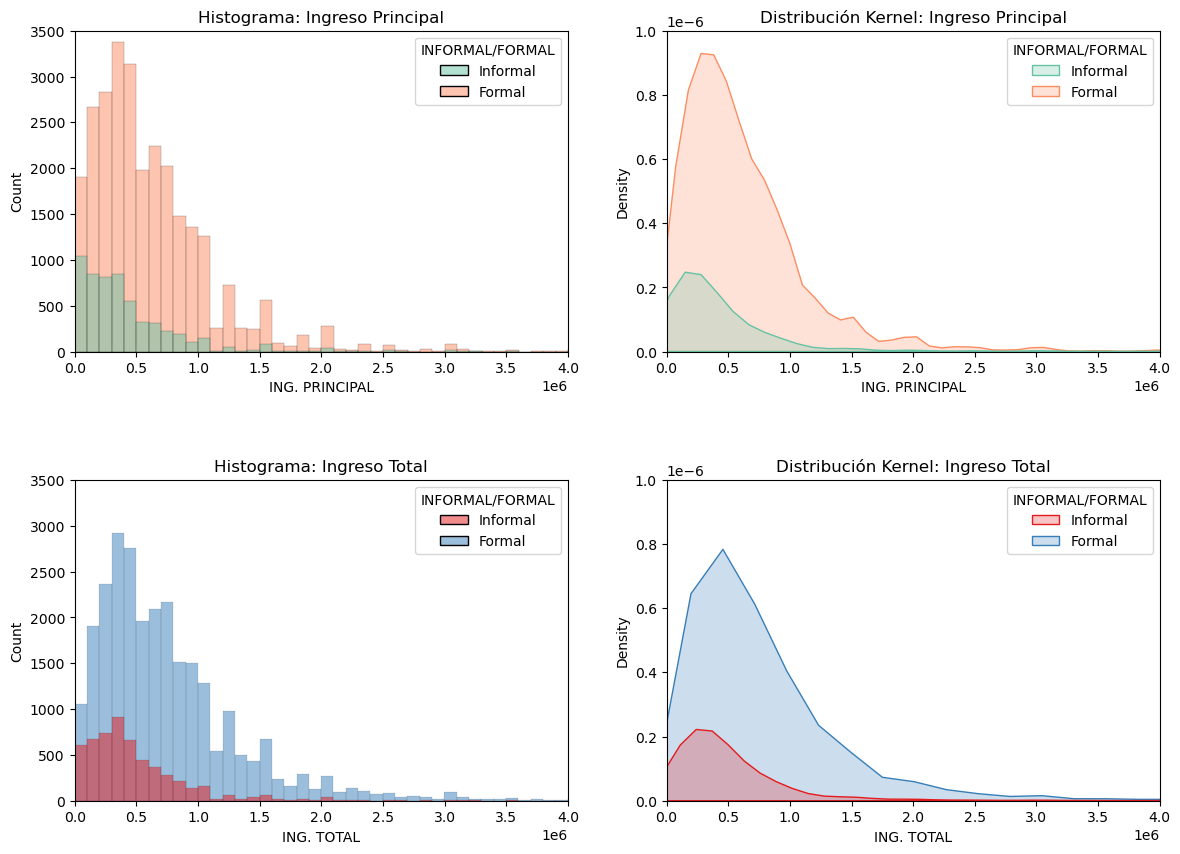

In [152]:
# grafico de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4)

# histograma de ingreso principal
sns.histplot(data=ocupados, x="ING. PRINCIPAL", hue="INFORMAL/FORMAL", kde=False, ax=axes[0,0], palette="Set2", binwidth=100000)
axes[0,0].set_title("Histograma: Ingreso Principal")
axes[0,0].set_xlim(0, 4000000)
axes[0,0].set_ylim(0, 3500)

# kernel de ingreso principal
sns.kdeplot(data=ocupados, x="ING. PRINCIPAL", hue="INFORMAL/FORMAL", fill=True, ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Distribución Kernel: Ingreso Principal")
axes[0,1].set_xlim(0, 4000000)
axes[0,1].set_ylim(0, 0.000001)

# histograma de ingreso total
sns.histplot(data=ocupados, x="ING. TOTAL", hue="INFORMAL/FORMAL", kde=False, ax=axes[1,0], palette="Set1", binwidth=100000)
axes[1,0].set_title("Histograma: Ingreso Total2)
axes[1,0].set_xlim(0, 4000000)
axes[1,0].set_ylim(0, 3500)

# kernel de ingreso total
sns.kdeplot(data=ocupados, x="ING. TOTAL", hue="INFORMAL/FORMAL", fill=True, ax=axes[1,1], palette="Set1")
axes[1,1].set_title("Distribución Kernel: Ingreso Total")
axes[1,1].set_xlim(0, 4000000)
axes[1,1].set_ylim(0, 0.000001)

plt.show()